
Exercises XP

Last Updated: June 10th, 2025

👩‍🏫 👩🏿‍🏫 What You’ll learn

    How to import and manipulate time-series data using pandas.
    Techniques for handling missing values in time-series data.
    Basic data visualization using matplotlib and seaborn.
    Building and training a simple LSTM model for time-series data analysis.


🛠️ What you will create

    A cleaned and preprocessed time-series dataset.
    Visualizations of the time-series data.
    A simple LSTM model to analyze and predict time-series data.


Dataset

Exercises XP

Last Updated: June 10th, 2025

👩‍🏫 👩🏿‍🏫 What You’ll learn

    How to import and manipulate time-series data using pandas.
    Techniques for handling missing values in time-series data.
    Basic data visualization using matplotlib and seaborn.
    Building and training a simple LSTM model for time-series data analysis.


🛠️ What you will create

    A cleaned and preprocessed time-series dataset.
    Visualizations of the time-series data.
    A simple LSTM model to analyze and predict time-series data.


Dataset

You will use this Dataset : household_power_consumption. You can find a description of the data here.


All “Part 1,” “Part 2,” etc., sections comprise one comprehensive exercise and are meant to be tackled sequentially as a single, continuous task.


Part 1 : Data Import and Initial Exploration

    Import the necessary libraries for data analysis and visualization.
    Load the time-series dataset from the provided file.
    Display the first few rows of the dataset to understand its structure.
    Check the data types of each column and the shape of the dataset.


Part 2 : Handling Missing Values

    Identify columns in the dataset that contain missing values.
    Fill the missing values using the mean of the respective columns.
    Verify that there are no more missing values in the dataset.


Part 3 : Data Visualization

    Resample the ‘Global_active_power’ column over a day and plot the sum and mean values.
    Create a plot showing the mean and standard deviation of the ‘Global_intensity’ column resampled over a day.


Part 4 : Data Preprocessing for LSTM

    Normalize the dataset to prepare it for LSTM model training.
    Split the dataset into training and testing sets.
    Reshape the data to fit the input requirements of an LSTM model.


Part 5 : Building an LSTM Model

    Import the necessary libraries for building an LSTM model.
    Define the architecture of the LSTM model, including the number of layers and neurons.
    Compile the model with an appropriate loss function and optimizer.


Part 6 : Training and Evaluating the LSTM Model

    Train the LSTM model on the training dataset.
    Evaluate the model’s performance on the testing dataset.
    Plot the training and validation loss to assess the model’s learning progress.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from IPython.display import Image, display
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    na_values="?",
    parse_dates=[[0, 1]],
    infer_datetime_format=True,
    low_memory=False
)

# 🧽 Renommer la colonne datetime
df.rename(columns={"Date_Time": "datetime"}, inplace=True)
df.set_index("datetime", inplace=True)

# 🖼️ Affichage initial
print("Aperçu des premières lignes :")
display(df.head())

print("\nForme du dataset :", df.shape)
print("\nTypes des colonnes :")
print(df.dtypes)

C:\Users\mathi\AppData\Local\Temp\ipykernel_37292\311333171.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
C:\Users\mathi\AppData\Local\Temp\ipykernel_37292\311333171.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
C:\Users\mathi\AppData\Local\Temp\ipykernel_37292\311333171.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


Aperçu des premières lignes :


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0



Forme du dataset : (2075259, 7)

Types des colonnes :
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


In [3]:
missing = df.isnull().sum()
print("Valeurs manquantes par colonne :\n", missing[missing > 0])

# Remplacer les valeurs manquantes par la moyenne
df.fillna(df.mean(numeric_only=True), inplace=True)

#  Vérification post-traitement
print("\nValeurs manquantes après remplissage :", df.isnull().sum().sum())

Valeurs manquantes par colonne :
 Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Valeurs manquantes après remplissage : 0


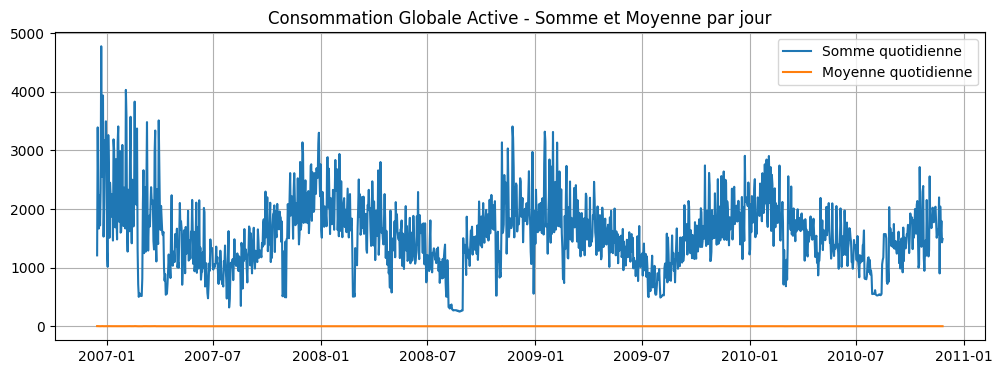

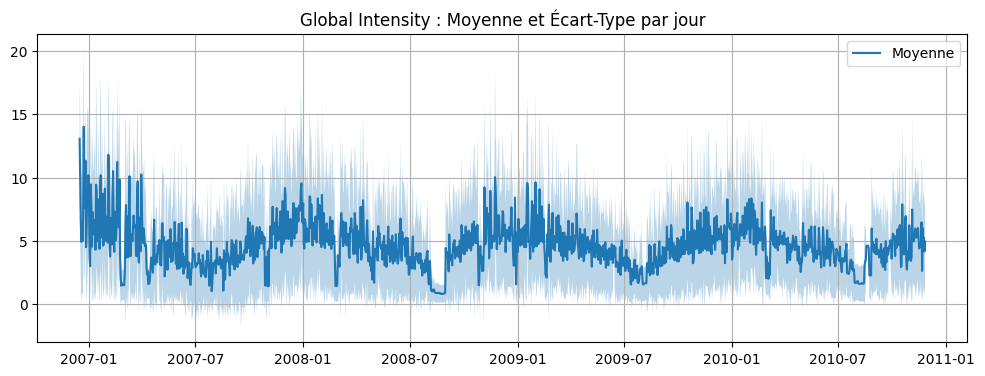

In [4]:
daily_power_sum = df["Global_active_power"].resample("D").sum()
daily_power_mean = df["Global_active_power"].resample("D").mean()

plt.figure(figsize=(12, 4))
plt.plot(daily_power_sum, label="Somme quotidienne")
plt.plot(daily_power_mean, label="Moyenne quotidienne")
plt.title("Consommation Globale Active - Somme et Moyenne par jour")
plt.legend()
plt.grid(True)
plt.show()

# 📈 Moyenne + Écart-type Global Intensity
daily_intensity = df["Global_intensity"].resample("D")
daily_mean = daily_intensity.mean()
daily_std = daily_intensity.std()

plt.figure(figsize=(12, 4))
plt.plot(daily_mean, label="Moyenne")
plt.fill_between(daily_mean.index, daily_mean - daily_std, daily_mean + daily_std, alpha=0.3)
plt.title("Global Intensity : Moyenne et Écart-Type par jour")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
data = df.select_dtypes(include=[np.number])

# Normalisation
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Créer des séquences pour LSTM
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length][0]  # On prédit la global_active_power
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LEN = 24 * 7  # 1 semaine de données (24h * 7j)
X, y = create_sequences(scaled_data, SEQ_LEN)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1660072, 168, 7)
X_test shape: (415019, 168, 7)


In [8]:
# Convertir en tensors PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64)

# Définir le modèle LSTM
class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super(SimpleLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, _ = self.lstm(x)
        output = self.fc(output[:, -1, :])  # dernière sortie
        return output.squeeze()

model = SimpleLSTM(input_size=X_train.shape[2])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Les differents test et plot ici ont été realisés sous collab , les resultats et images sauvegardés et affichés ici.

In [ ]:
EPOCHS = 10
train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Évaluation test
    model.eval()
    with torch.no_grad():
        test_loss = 0
        for xb, yb in test_loader:
            preds = model(xb)
            loss = criterion(preds, yb)
            test_loss += loss.item()
        test_loss /= len(test_loader)
        test_losses.append(test_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

Epoch 1/10 | Train Loss: 0.0028 | Test Loss: 0.0014
Epoch 2/10 | Train Loss: 0.0017 | Test Loss: 0.0015
Epoch 3/10 | Train Loss: 0.0017 | Test Loss: 0.0013
Epoch 4/10 | Train Loss: 0.0016 | Test Loss: 0.0013
Epoch 5/10 | Train Loss: 0.0016 | Test Loss: 0.0014
Epoch 6/10 | Train Loss: 0.0015 | Test Loss: 0.0013
Epoch 7/10 | Train Loss: 0.0015 | Test Loss: 0.0013
Epoch 8/10 | Train Loss: 0.0014 | Test Loss: 0.0012
Epoch 9/10 | Train Loss: 0.0013 | Test Loss: 0.0012
Epoch 10/10 | Train Loss: 0.0012 | Test Loss: 0.0012

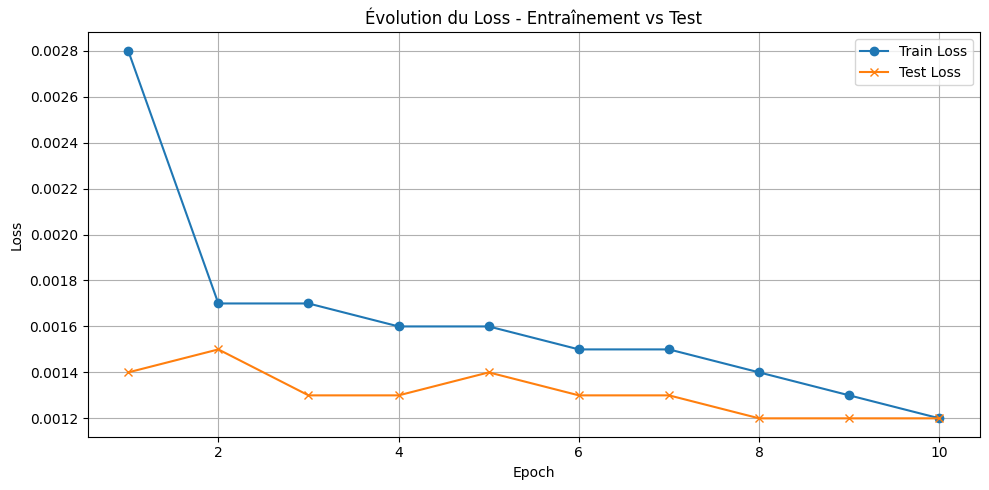

In [5]:
train_losses = [0.0028, 0.0017, 0.0017, 0.0016, 0.0016, 0.0015, 0.0015, 0.0014, 0.0013, 0.0012]
test_losses  = [0.0014, 0.0015, 0.0013, 0.0013, 0.0014, 0.0013, 0.0013, 0.0012, 0.0012, 0.0012]

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, test_losses, label='Test Loss', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Évolution du Loss - Entraînement vs Test')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Prédictions
model.eval()
with torch.no_grad():
    predictions = model(X_test_t).cpu().numpy()

# Re-transformer les valeurs (inverse de MinMaxScaler)
y_test_orig = scaler.inverse_transform(
    np.concatenate([y_test.reshape(-1, 1), np.zeros((len(y_test), scaled_data.shape[1] - 1))], axis=1)
)[:, 0]

predictions_orig = scaler.inverse_transform(
    np.concatenate([predictions.reshape(-1, 1), np.zeros((len(predictions), scaled_data.shape[1] - 1))], axis=1)
)[:, 0]

# Visualisation
plt.figure(figsize=(12, 4))
plt.plot(y_test_orig, label="Valeurs réelles")
plt.plot(predictions_orig, label="Prédictions LSTM")
plt.title("Comparaison entre Réel et Prédit")
plt.xlabel("Time step")
plt.ylabel("Global Active Power")
plt.legend()
plt.grid(True)
plt.show()

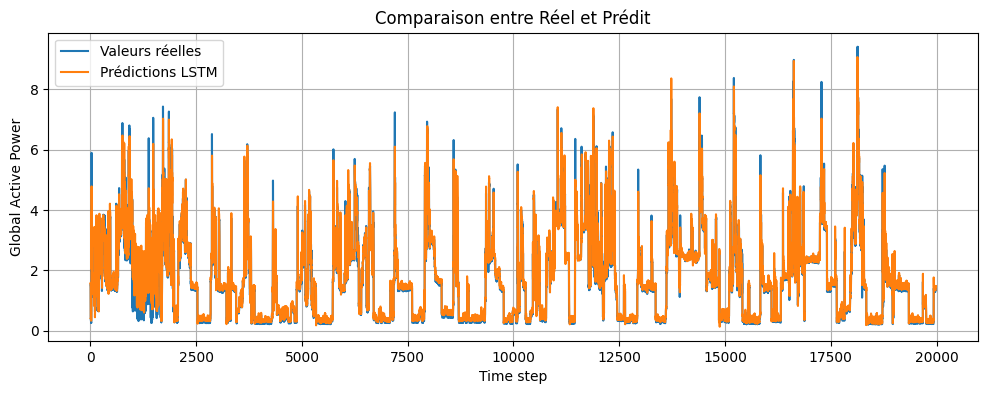

In [8]:
display(Image(filename="eval_predict.png"))

In [ ]:
r2 = r2_score(y_test_orig, predictions_orig)
print(f"R² Score final : {r2:.4f}")

R² Score final : 0.9479